<a href="https://colab.research.google.com/github/Hernandez484/01.01-PROYECTO-KAGGLE/blob/main/01%20-%20exploraci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

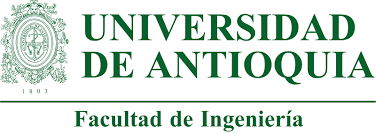

# <font color='056938'> **01.01 - PROYECTO KAGGLE - </font> <font color='8EC044'> Entrega 1** </font>

## <font color='157699'> **Paso 1:** </font>

In [ ]:
!wget --no-cache -O init.py -q https://raw.githubusercontent.com/rramosp/ai4eng.v1/main/content/init.py
import init; init.init(force_download=False); init.get_weblink()

replicating local resources


## <font color='157699'> **Paso 2: Descargar datos directamente desde Kaggle** </font>

- Se creo un archivo kaggle.jsoncon con mi token de autenticación (en kaggle $\to$ Hago clic en el icono de usuario en la parte superior derecha $\to$
ajustes $\to$ API crea un nuevo token);

- Subirlo a este espacio de trabajo del cuaderno;

- Y ejecutar la siguiente celda.

In [ ]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '.'
!chmod 600 ./kaggle.json
!kaggle competitions download --force udea-ai4eng-20242

  0% 0.00/20.1M [00:00<?, ?B/s]
100% 20.1M/20.1M [00:00<00:00, 1.32GB/s]


## <font color='157699'> **Paso 3: Descomprimir e inspeccionar datos** </font>

Se descomprime el fichero.

In [ ]:
!unzip udea*.zip > /dev/null

In [ ]:
!wc *.csv

   296787    296787   4716673 submission_example.csv
   296787   4565553  50135751 test.csv
   692501  10666231 118025055 train.csv
  1286075  15528571 172877479 total


## <font color='157699'> **Paso 4: Se carga `train.csv` y `test.csv` con la librería `Pandas`** </font>

In [ ]:
import pandas as pd
import numpy as np

z = pd.read_csv("train.csv")
x = pd.read_csv("test.csv")
print ("shape of loaded dataframe", z.shape)

shape of loaded dataframe (692500, 12)


Se muestran los datos del archivo de entrenamiento.

In [ ]:
z.head()

,ID,PERIODO,ESTU_PRGM_ACADEMICO,ESTU_PRGM_DEPARTAMENTO,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_EDUCACIONPADRE,FAMI_EDUCACIONMADRE,ESTU_PAGOMATRICULAPROPIO,RENDIMIENTO_GLOBAL
0,904256,20212,ENFERMERIA,BOGOTÁ,Entre 5.5 millones y menos de 7 millones,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica incompleta,Postgrado,No,medio-alto
1,645256,20212,DERECHO,ATLANTICO,Entre 2.5 millones y menos de 4 millones,0,Estrato 3,No,Técnica o tecnológica completa,Técnica o tecnológica incompleta,No,bajo
2,308367,20203,MERCADEO Y PUBLICIDAD,BOGOTÁ,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 3,Si,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,No,bajo
3,470353,20195,ADMINISTRACION DE EMPRESAS,SANTANDER,Entre 4 millones y menos de 5.5 millones,0,Estrato 4,Si,No sabe,Secundaria (Bachillerato) completa,No,alto
4,989032,20212,PSICOLOGIA,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 3,Si,Primaria completa,Primaria completa,No,medio-bajo


Se muestran los datos del archivo de prueba.

In [ ]:
x.head()

,Unnamed: 0,ID,PERIODO,ESTU_PRGM_ACADEMICO,ESTU_PRGM_DEPARTAMENTO,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_EDUCACIONPADRE,FAMI_EDUCACIONMADRE,ESTU_PAGOMATRICULAPROPIO
0,0,550236,20183,TRABAJO SOCIAL,BOLIVAR,Menos de 500 mil,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Primaria completa,Si
1,1,98545,20203,ADMINISTRACION COMERCIAL Y DE MERCADEO,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Técnica o tecnológica completa,No
2,2,499179,20212,INGENIERIA MECATRONICA,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Secundaria (Bachillerato) completa,No
3,3,782980,20195,CONTADURIA PUBLICA,SUCRE,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Primaria incompleta,No
4,4,785185,20212,ADMINISTRACION DE EMPRESAS,ATLANTICO,Entre 2.5 millones y menos de 4 millones,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,No


## <font color='157699'> **Paso 5: Explaración de datos usando `train.CSV` y `test.CSV`** </font>

Se muestran los 10 primeros elementos del archivo de entrenamiento.

In [ ]:
z.head(10)

,PERIODO,FAMI_ESTRATOVIVIENDA,FAMI_EDUCACIONPADRE,FAMI_EDUCACIONMADRE,ESTU_PAGOMATRICULAPROPIO,ESTU_HORASSEMANATRABAJA,ESTU_VALORMATRICULAUNIVERSIDAD,RENDIMIENTO_GLOBAL
0,20212,Estrato 3,Técnica o tecnológica incompleta,Postgrado,No,Menos de 10 horas,Entre 5.5 millones y menos de 7 millones,medio-alto
1,20212,Estrato 3,Técnica o tecnológica completa,Técnica o tecnológica incompleta,No,0,Entre 2.5 millones y menos de 4 millones,bajo
2,20203,Estrato 3,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,No,Más de 30 horas,Entre 2.5 millones y menos de 4 millones,bajo
3,20195,Estrato 4,No sabe,Secundaria (Bachillerato) completa,No,0,Entre 4 millones y menos de 5.5 millones,alto
4,20212,Estrato 3,Primaria completa,Primaria completa,No,Entre 21 y 30 horas,Entre 2.5 millones y menos de 4 millones,medio-bajo
5,20203,Estrato 5,Educación profesional completa,Secundaria (Bachillerato) completa,No,Menos de 10 horas,Más de 7 millones,medio-alto
6,20183,Estrato 2,Educación profesional incompleta,Técnica o tecnológica completa,Si,Entre 21 y 30 horas,Entre 2.5 millones y menos de 4 millones,alto
7,20183,Estrato 2,Primaria incompleta,Secundaria (Bachillerato) incompleta,Si,Entre 11 y 20 horas,Entre 1 millón y menos de 2.5 millones,medio-bajo
8,20212,Estrato 1,Secundaria (Bachillerato) completa,Educación profesional incompleta,Si,Menos de 10 horas,Entre 5.5 millones y menos de 7 millones,medio-bajo
9,20183,Estrato 5,Postgrado,Postgrado,Si,Más de 30 horas,Entre 2.5 millones y menos de 4 millones,alto


Se muestran los 10 últimos elementos del archivo entrenamiento.

In [ ]:
z.tail(10)

,PERIODO,FAMI_ESTRATOVIVIENDA,FAMI_EDUCACIONPADRE,FAMI_EDUCACIONMADRE,ESTU_PAGOMATRICULAPROPIO,ESTU_HORASSEMANATRABAJA,ESTU_VALORMATRICULAUNIVERSIDAD,RENDIMIENTO_GLOBAL
692490,20195,Estrato 2,Técnica o tecnológica incompleta,Secundaria (Bachillerato) completa,No,Entre 21 y 30 horas,Entre 2.5 millones y menos de 4 millones,alto
692491,20212,Estrato 2,Educación profesional completa,Secundaria (Bachillerato) completa,No,Entre 21 y 30 horas,No pagó matrícula,medio-alto
692492,20183,Estrato 1,Primaria incompleta,Primaria incompleta,Si,Menos de 10 horas,Menos de 500 mil,alto
692493,20203,Estrato 1,Educación profesional incompleta,Educación profesional completa,No,Más de 30 horas,Entre 2.5 millones y menos de 4 millones,medio-alto
692494,20212,Estrato 3,Secundaria (Bachillerato) incompleta,Secundaria (Bachillerato) completa,Si,Entre 21 y 30 horas,Menos de 500 mil,bajo
692495,20195,Estrato 2,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) incompleta,Si,Entre 11 y 20 horas,Entre 500 mil y menos de 1 millón,medio-alto
692496,20212,Estrato 3,Primaria incompleta,Secundaria (Bachillerato) incompleta,No,Más de 30 horas,Entre 2.5 millones y menos de 4 millones,bajo
692497,20183,Estrato 3,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) incompleta,Si,Menos de 10 horas,Entre 1 millón y menos de 2.5 millones,medio-bajo
692498,20195,Estrato 1,Primaria completa,Primaria completa,Si,Menos de 10 horas,Entre 2.5 millones y menos de 4 millones,bajo
692499,20195,Estrato 4,Secundaria (Bachillerato) completa,Técnica o tecnológica completa,No,Más de 30 horas,Entre 5.5 millones y menos de 7 millones,alto


Se muestran los 10 primeros elementos del archivo de prueba.

In [ ]:
x.head (10)

,Unnamed: 0,ID,PERIODO,ESTU_PRGM_ACADEMICO,ESTU_PRGM_DEPARTAMENTO,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_EDUCACIONPADRE,FAMI_EDUCACIONMADRE,ESTU_PAGOMATRICULAPROPIO
0,0,550236,20183,TRABAJO SOCIAL,BOLIVAR,Menos de 500 mil,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Primaria completa,Si
1,1,98545,20203,ADMINISTRACION COMERCIAL Y DE MERCADEO,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Técnica o tecnológica completa,No
2,2,499179,20212,INGENIERIA MECATRONICA,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Secundaria (Bachillerato) completa,No
3,3,782980,20195,CONTADURIA PUBLICA,SUCRE,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Primaria incompleta,No
4,4,785185,20212,ADMINISTRACION DE EMPRESAS,ATLANTICO,Entre 2.5 millones y menos de 4 millones,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,No
5,5,58495,20183,ADMINISTRACION AGROPECUARIA,VALLE,Entre 500 mil y menos de 1 millón,Más de 30 horas,Estrato 1,Si,Ninguno,Secundaria (Bachillerato) completa,Si
6,6,705444,20195,INGENIERIA CIVIL,SANTANDER,Menos de 500 mil,0,Estrato 3,Si,Primaria completa,Técnica o tecnológica completa,No
7,7,557548,20183,INGENIERÍA MECÁNICA,BOGOTÁ,Más de 7 millones,Menos de 10 horas,Estrato 4,Si,Postgrado,Postgrado,No
8,8,519909,20195,INGENIERÍA DE SISTEMAS,ATLANTICO,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 2,No,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,No
9,9,832058,20183,ECONOMIA,BOGOTÁ,Entre 500 mil y menos de 1 millón,Entre 21 y 30 horas,Estrato 2,Si,Técnica o tecnológica completa,Secundaria (Bachillerato) incompleta,No


Se muestran los 10 últimos elementos del archivo de prueba.

In [ ]:
x.tail(10)

,Unnamed: 0,ID,PERIODO,ESTU_PRGM_ACADEMICO,ESTU_PRGM_DEPARTAMENTO,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_EDUCACIONPADRE,FAMI_EDUCACIONMADRE,ESTU_PAGOMATRICULAPROPIO
296776,296776,718143,20203,INGENIERIA INDUSTRIAL,BOLIVAR,Entre 1 millón y menos de 2.5 millones,0,Estrato 2,Si,Educación profesional completa,Educación profesional completa,No
296777,296777,516832,20195,MERCADEO,ANTIOQUIA,Más de 7 millones,Más de 30 horas,Estrato 6,Si,Secundaria (Bachillerato) incompleta,Secundaria (Bachillerato) completa,No
296778,296778,438542,20183,INGENIERIA AMBIENTAL,BOGOTÁ,Entre 5.5 millones y menos de 7 millones,Entre 11 y 20 horas,Estrato 5,NaN,Educación profesional completa,Educación profesional completa,No
296779,296779,977130,20212,ADMINISTRACIÓN DE EMPRESAS,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,Más de 30 horas,Estrato 3,Si,Primaria incompleta,Primaria incompleta,Si
296780,296780,229699,20195,CONTADURÍA PÚBLICA,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,Menos de 10 horas,Estrato 2,Si,Ninguno,Técnica o tecnológica incompleta,No
296781,296781,496981,20195,ADMINISTRACION DE EMPRESAS,BOGOTÁ,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 1,Si,Primaria incompleta,Primaria incompleta,Si
296782,296782,209415,20183,DERECHO,META,Entre 1 millón y menos de 2.5 millones,0,Estrato 4,Si,Educación profesional completa,Educación profesional completa,No
296783,296783,239074,20212,DERECHO,BOGOTÁ,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 3,Si,Secundaria (Bachillerato) completa,Educación profesional completa,No
296784,296784,963852,20195,INGENIERIA AERONAUTICA,ANTIOQUIA,Entre 5.5 millones y menos de 7 millones,Entre 11 y 20 horas,Estrato 3,Si,Educación profesional completa,Educación profesional completa,No
296785,296785,792650,20212,INGENIERIA INDUSTRIAL,BOYACA,No pagó matrícula,0,Estrato 3,Si,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,No


Se verifica que los ID sean todos distintos

In [ ]:
x ['ID'].nunique()

296786

Se elimina la columna 'Unnamed: 0' ya que posee el mismo conteo que el index y no es relevante.

In [ ]:
x = x.drop(columns=['Unnamed: 0'])

Cambiamos el index por los ID ya que son unicos, en el dataframe del archivo de prueba ya estaba seteado el index 'ID'

In [ ]:
z.set_index('ID', inplace=True)
x.set_index('ID', inplace=True)

Observamos como quedaron nuestros dataframes

In [ ]:
z.head()

,PERIODO,ESTU_PRGM_ACADEMICO,ESTU_PRGM_DEPARTAMENTO,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_EDUCACIONPADRE,FAMI_EDUCACIONMADRE,ESTU_PAGOMATRICULAPROPIO,RENDIMIENTO_GLOBAL
ID,,,,,,,,,,,
904256,20212,ENFERMERIA,BOGOTÁ,Entre 5.5 millones y menos de 7 millones,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica incompleta,Postgrado,No,medio-alto
645256,20212,DERECHO,ATLANTICO,Entre 2.5 millones y menos de 4 millones,0,Estrato 3,No,Técnica o tecnológica completa,Técnica o tecnológica incompleta,No,bajo
308367,20203,MERCADEO Y PUBLICIDAD,BOGOTÁ,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 3,Si,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,No,bajo
470353,20195,ADMINISTRACION DE EMPRESAS,SANTANDER,Entre 4 millones y menos de 5.5 millones,0,Estrato 4,Si,No sabe,Secundaria (Bachillerato) completa,No,alto
989032,20212,PSICOLOGIA,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 3,Si,Primaria completa,Primaria completa,No,medio-bajo


In [ ]:
x.head()

,PERIODO,ESTU_PRGM_ACADEMICO,ESTU_PRGM_DEPARTAMENTO,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_EDUCACIONPADRE,FAMI_EDUCACIONMADRE,ESTU_PAGOMATRICULAPROPIO
ID,,,,,,,,,,
550236,20183,TRABAJO SOCIAL,BOLIVAR,Menos de 500 mil,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Primaria completa,Si
98545,20203,ADMINISTRACION COMERCIAL Y DE MERCADEO,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Técnica o tecnológica completa,No
499179,20212,INGENIERIA MECATRONICA,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Secundaria (Bachillerato) completa,No
782980,20195,CONTADURIA PUBLICA,SUCRE,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Primaria incompleta,No
785185,20212,ADMINISTRACION DE EMPRESAS,ATLANTICO,Entre 2.5 millones y menos de 4 millones,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,No


Buscamos conocer qué tipo de dato tiene cada una de las columnas y al correrlo observamos que hay 11 columnas, 1 de tipo entero y 10 de tipo object.

In [ ]:
z.dtypes

,0
PERIODO,int64
ESTU_PRGM_ACADEMICO,object
ESTU_PRGM_DEPARTAMENTO,object
ESTU_VALORMATRICULAUNIVERSIDAD,object
ESTU_HORASSEMANATRABAJA,object
FAMI_ESTRATOVIVIENDA,object
FAMI_TIENEINTERNET,object
FAMI_EDUCACIONPADRE,object
FAMI_EDUCACIONMADRE,object
ESTU_PAGOMATRICULAPROPIO,object


In [ ]:
x.dtypes

,0
PERIODO,int64
ESTU_PRGM_ACADEMICO,object
ESTU_PRGM_DEPARTAMENTO,object
ESTU_VALORMATRICULAUNIVERSIDAD,object
ESTU_HORASSEMANATRABAJA,object
FAMI_ESTRATOVIVIENDA,object
FAMI_TIENEINTERNET,object
FAMI_EDUCACIONPADRE,object
FAMI_EDUCACIONMADRE,object
ESTU_PAGOMATRICULAPROPIO,object


Con el siguiente bloque de código podemos saber si hay datos faltantes. Para cada columna hay 692500 datos; al correr el código se observa que no falta ningún punto de datos.

In [ ]:
z.notnull().count()

,0
PERIODO,692500
ESTU_PRGM_ACADEMICO,692500
ESTU_PRGM_DEPARTAMENTO,692500
ESTU_VALORMATRICULAUNIVERSIDAD,692500
ESTU_HORASSEMANATRABAJA,692500
FAMI_ESTRATOVIVIENDA,692500
FAMI_TIENEINTERNET,692500
FAMI_EDUCACIONPADRE,692500
FAMI_EDUCACIONMADRE,692500
ESTU_PAGOMATRICULAPROPIO,692500


Observamos cuantos departamentos distintos hay.

In [ ]:
z ['ESTU_PRGM_DEPARTAMENTO'].unique()

array(['BOGOTÁ', 'ATLANTICO', 'SANTANDER', 'ANTIOQUIA', 'HUILA', 'SUCRE',
       'CAQUETA', 'CUNDINAMARCA', 'BOLIVAR', 'TOLIMA', 'VALLE', 'QUINDIO',
       'RISARALDA', 'CORDOBA', 'META', 'LA GUAJIRA', 'BOYACA', 'NARIÑO',
       'CAUCA', 'NORTE SANTANDER', 'CESAR', 'PUTUMAYO', 'CALDAS',
       'MAGDALENA', 'CHOCO', 'CASANARE', 'ARAUCA', 'GUAVIARE', 'AMAZONAS',
       'VAUPES', 'SAN ANDRES'], dtype=object)

In [ ]:
z ['ESTU_VALORMATRICULAUNIVERSIDAD'].unique()

array(['Entre 5.5 millones y menos de 7 millones',
       'Entre 2.5 millones y menos de 4 millones',
       'Entre 4 millones y menos de 5.5 millones', 'Más de 7 millones',
       'Entre 1 millón y menos de 2.5 millones',
       'Entre 500 mil y menos de 1 millón', 'Menos de 500 mil',
       'No pagó matrícula', nan], dtype=object)

Observamos cuantos rangos de horas de estudio distintos hay.

In [ ]:
z ['ESTU_HORASSEMANATRABAJA'].unique()

array(['Menos de 10 horas', '0', 'Más de 30 horas', 'Entre 21 y 30 horas',
       'Entre 11 y 20 horas', nan], dtype=object)

Como hay lugares de la columna con NaN, estos se van a reemplazar por 'No sabe, No responde'

In [ ]:
z ['ESTU_HORASSEMANATRABAJA'].fillna(value = 'No sabe, No responde', inplace = True)

Verificamos que haya quedado guardado

In [ ]:
z ['ESTU_HORASSEMANATRABAJA'].unique()

array(['Menos de 10 horas', '0', 'Más de 30 horas', 'Entre 21 y 30 horas',
       'Entre 11 y 20 horas', 'No sabe, no responde'], dtype=object)

Miramos que mas datos faltantes hay por columna.

In [ ]:
z.isna().sum()

,0
PERIODO,0
ESTU_PRGM_ACADEMICO,0
ESTU_PRGM_DEPARTAMENTO,0
ESTU_VALORMATRICULAUNIVERSIDAD,6287
ESTU_HORASSEMANATRABAJA,0
FAMI_ESTRATOVIVIENDA,32137
FAMI_TIENEINTERNET,26629
FAMI_EDUCACIONPADRE,23178
FAMI_EDUCACIONMADRE,23664
ESTU_PAGOMATRICULAPROPIO,6498


Reemplazamos los datos faltantes por valores dependiendo de cada columna, así:

ESTU_VALORMATRICULAUNIVERSIDAD = 'No sabe, No responde'
FAMI_ESTRATOVIVIENDA = 'Sin Estrato'
FAMI_TIENEINTERNET = 'No'
FAMI_EDUCACIONPADRE = 'No Aplica'
FAMI_EDUCACIONMADRE = 'No Aplica'
ESTU_PAGOMATRICULAPROPIO = 'No sabe, No responde'

In [ ]:
z ['ESTU_VALORMATRICULAUNIVERSIDAD'].fillna(value='No sabe, No responde', inplace=True)
z ['FAMI_ESTRATOVIVIENDA'].fillna(value='Sin Estrato', inplace=True)
z ['FAMI_TIENEINTERNET'].fillna(value='No', inplace=True)
z ['FAMI_EDUCACIONPADRE'].fillna(value='No Aplica', inplace=True)
z ['FAMI_EDUCACIONMADRE'].fillna(value='No Aplica', inplace=True)
z ['ESTU_PAGOMATRICULAPROPIO'].fillna(value='No sabe, No responde', inplace=True)

Verificamos que haya quedado guardado

In [ ]:
z ['ESTU_VALORMATRICULAUNIVERSIDAD'].unique()
z ['FAMI_ESTRATOVIVIENDA'].unique()
z ['FAMI_TIENEINTERNET'].unique()
z ['FAMI_EDUCACIONPADRE'].unique()
z ['FAMI_EDUCACIONMADRE'].unique()
z ['ESTU_PAGOMATRICULAPROPIO'].unique()

array(['No', 'Si', 'No sabe, No responde'], dtype=object)

Ahora vamos a mirar cuantos estudiantes hay por localidades.

In [ ]:
z.groupby('ESTU_PRGM_DEPARTAMENTO').count()['ESTU_PRGM_ACADEMICO']

,ESTU_PRGM_ACADEMICO
ESTU_PRGM_DEPARTAMENTO,
AMAZONAS,40
ANTIOQUIA,83607
ARAUCA,589
ATLANTICO,41020
BOGOTÁ,282159
BOLIVAR,20629
BOYACA,14048
CALDAS,11640
CAQUETA,2659


Se muestra una gráfica con la cantidad de estudiantes por departamento, como era de esperarse, la mayoría de estudiantes son de los departamentos mas desarrolados, los cuales son en orden descendente: Bogotá, Antioquia, Valle, Atlantico y Santander.

In [1]:
z.groupby('ESTU_PRGM_DEPARTAMENTO').count()['ESTU_PRGM_ACADEMICO'].plot(y='ESTU_PRGM_ACADEMICO', kind='bar')

NameError: name 'z' is not defined

Ahora vamos a observar la cantidad de estudiantes por clase.

<Axes: xlabel='FAMI_EDUCACIONPADRE'>

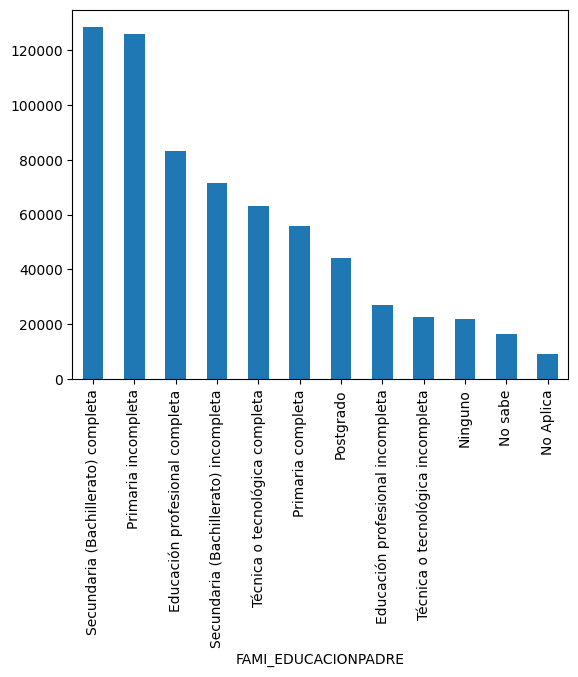

In [ ]:
z.groupby('ESTU_PRGM_ACADEMICO').count()['ESTU_PRGM_DEPARTAMENTO']

Observamos el programa academico con menos personas inscritas.

In [ ]:
z.groupby('ESTU_PRGM_ACADEMICO').count()['ESTU_PRGM_DEPARTAMENTO'].idxmin(), df_train.groupby('ESTU_PRGM_ACADEMICO').count()['ESTU_PRGM_DEPARTAMENTO'].min()

Observamos el programa academico con más personas inscritas

In [ ]:
z.groupby('ESTU_PRGM_ACADEMICO').count()['ESTU_PRGM_DEPARTAMENTO'].idxmax(),  df_train.groupby('ESTU_PRGM_ACADEMICO').count()['ESTU_PRGM_DEPARTAMENTO'].max()

Ahora, vamos a observar cuantos estudiantes hay de cada clase por departamento.

In [ ]:
pd.crosstab(z ['ESTU_PRGM_DEPARTAMENTO'], z ['ESTU_PRGM_ACADEMICO'], margins = True)

Ahora observaremos la incidencia de la educación del padre con el rendimiento.

In [ ]:
pd.crosstab(z ['FAMI_EDUCACIONPADRE'], z ['RENDIMIENTO_GLOBAL'], margins = True)

Ahora observaremos la incidencia de la educación de la madre con el rendimiento.

In [ ]:
pd.crosstab(z ['FAMI_EDUCACIONMADRE'], z ['RENDIMIENTO_GLOBAL'], margins = True)

Incidencia del estrato en el valor de matricula pagado en la universidad.

In [ ]:
pd.crosstab(z ['ESTU_VALORMATRICULAUNIVERSIDAD'], z ['FAMI_ESTRATOVIVIENDA'], margins = True)

Cantidad de estudiantes por valor de matricula pagado en la universidad.

In [ ]:
z.groupby('ESTU_VALORMATRICULAUNIVERSIDAD').count()['ESTU_PRGM_ACADEMICO']

Gráfico de barras que muestra la información anterior.

<Axes: xlabel='FAMI_EDUCACIONMADRE'>

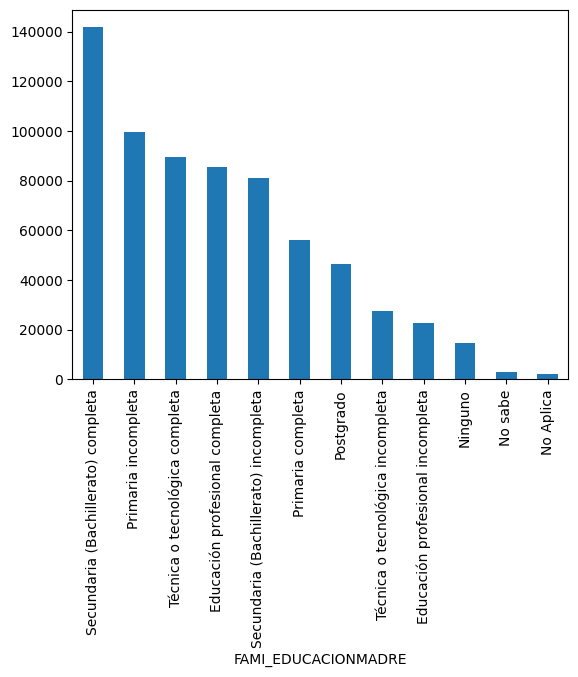

In [ ]:
z.groupby('ESTU_VALORMATRICULAUNIVERSIDAD').count()['ESTU_PRGM_ACADEMICO'].plot(y='ESTU_PRGM_ACADEMICO', kind='bar')

## <font color='157699'> **Paso 6: Inspeccionar visualmente si los atributos del Modelo 1, tienen un comportamiento distintivo con respecto a lo que se quiere predecir** </font>

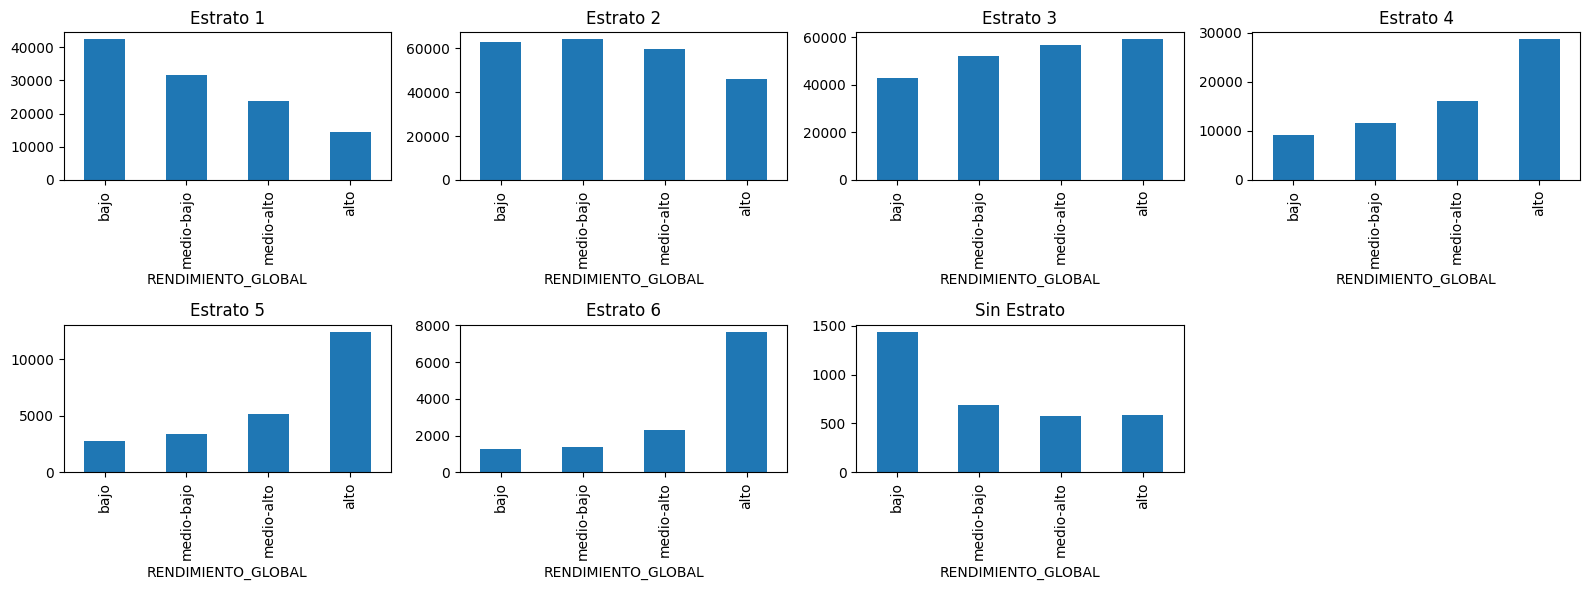

In [ ]:
from rlxutils import subplots
import matplotlib.pyplot as plt

c = sorted(z.FAMI_ESTRATOVIVIENDA.value_counts().index)
for ax,ci in subplots(c, n_cols=4, usizex=4):
    zc = z[z.FAMI_ESTRATOVIVIENDA==ci]
    zc.RENDIMIENTO_GLOBAL.value_counts()[['bajo', 'medio-bajo', 'medio-alto', 'alto']].plot(kind='bar')
    plt.title(ci)

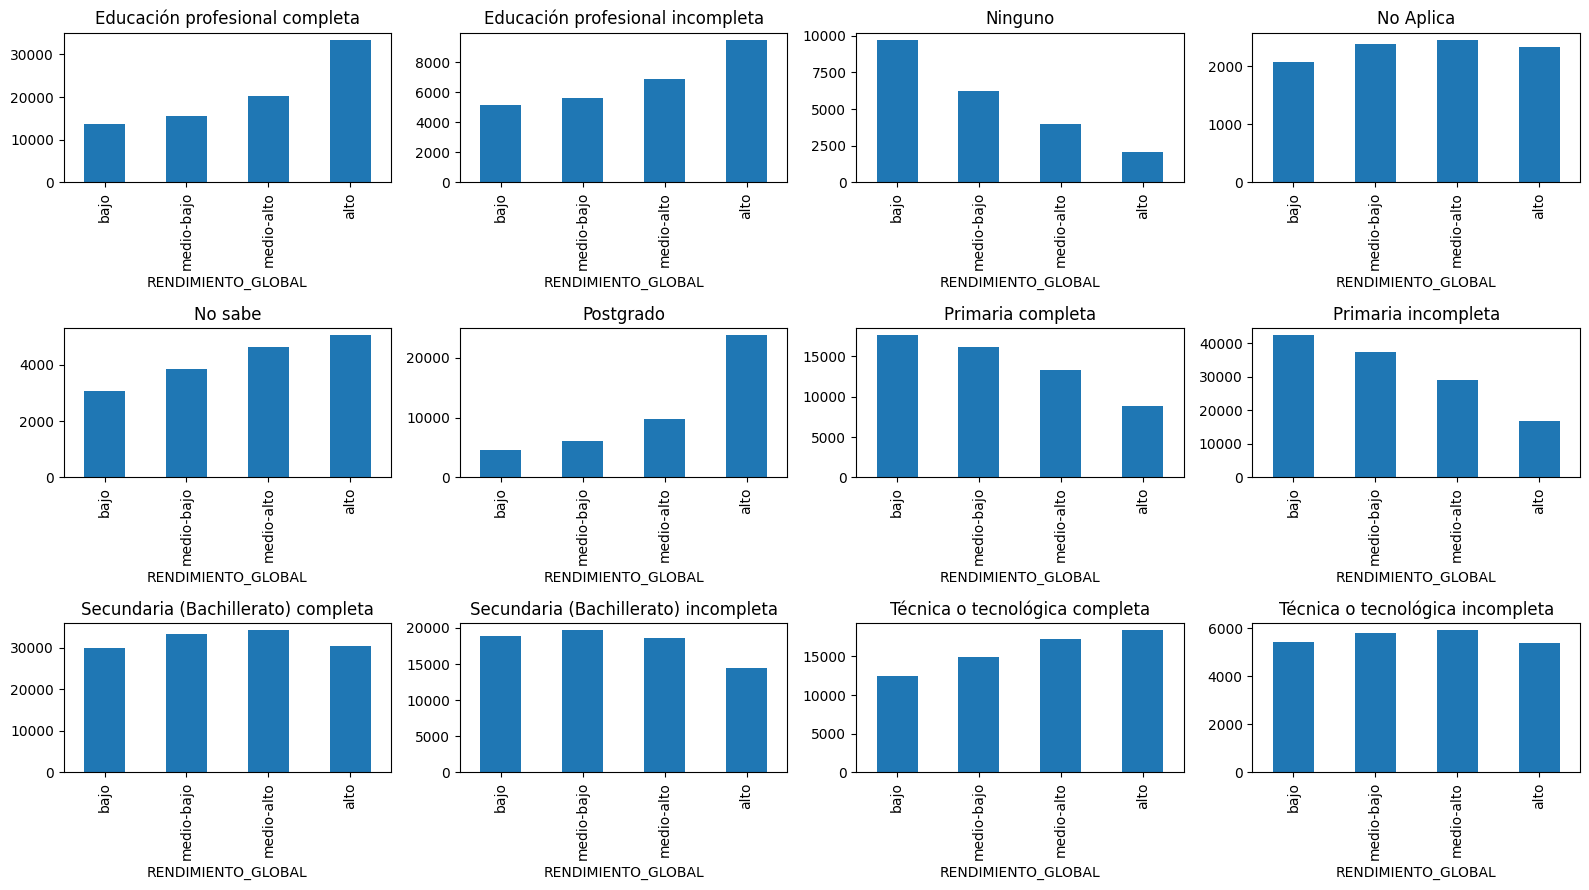

In [ ]:
from rlxutils import subplots
import matplotlib.pyplot as plt

c = sorted(z.FAMI_EDUCACIONPADRE.value_counts().index)
for ax,ci in subplots(c, n_cols=4, usizex=4):
    zc = z[z.FAMI_EDUCACIONPADRE==ci]
    zc.RENDIMIENTO_GLOBAL.value_counts()[['bajo', 'medio-bajo', 'medio-alto', 'alto']].plot(kind='bar')
    plt.title(ci)

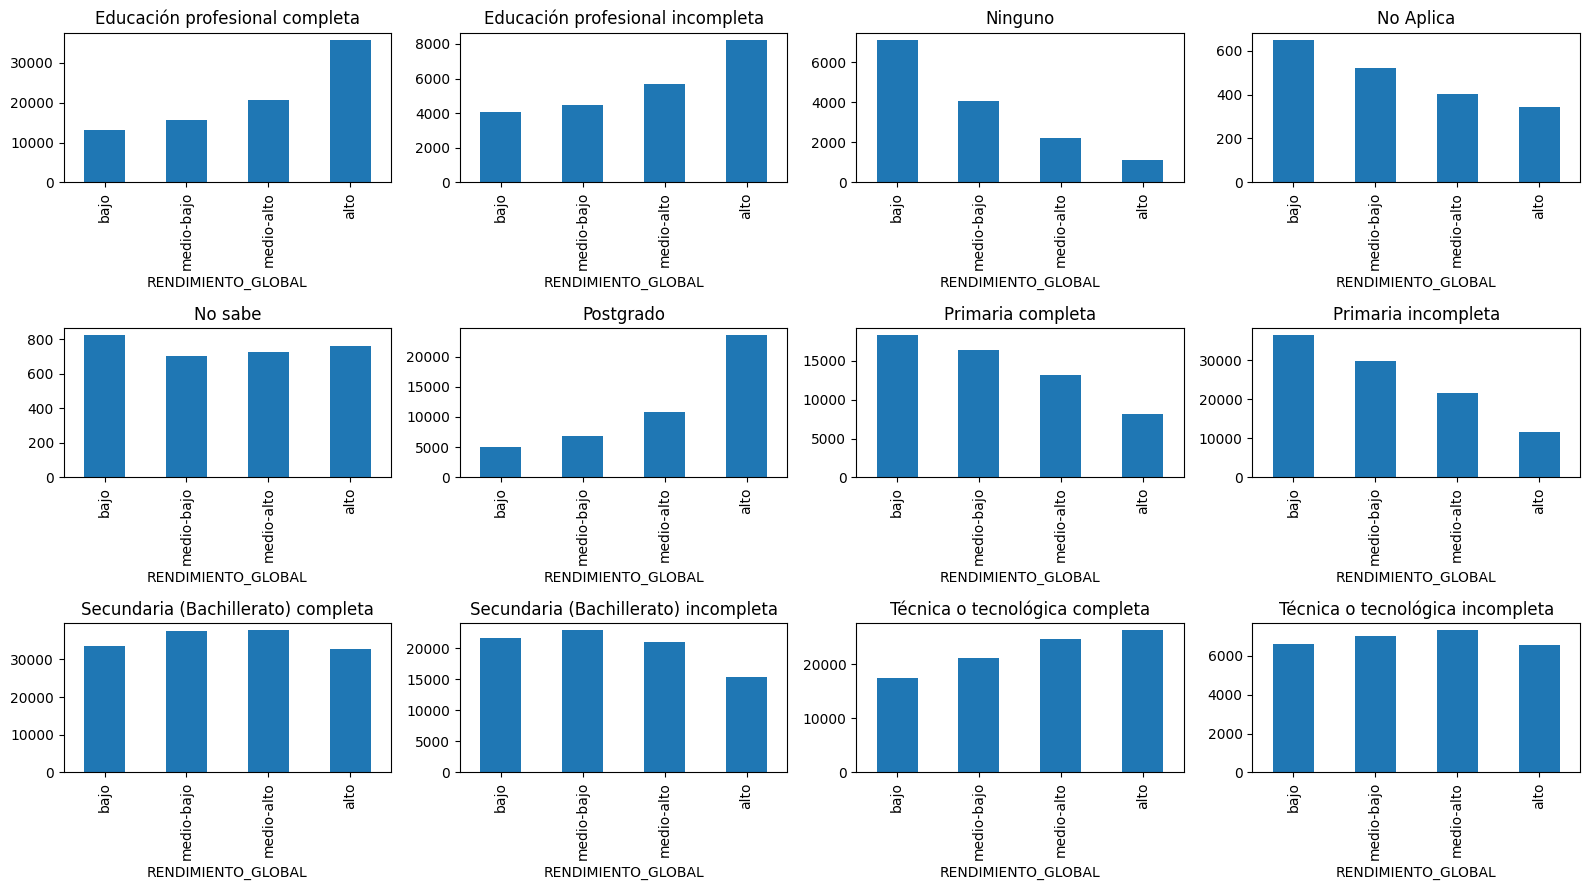

In [ ]:
from rlxutils import subplots
import matplotlib.pyplot as plt

c = sorted(z.FAMI_EDUCACIONMADRE.value_counts().index)
for ax,ci in subplots(c, n_cols=4, usizex=4):
    zc = z[z.FAMI_EDUCACIONMADRE==ci]
    zc.RENDIMIENTO_GLOBAL.value_counts()[['bajo', 'medio-bajo', 'medio-alto', 'alto']].plot(kind='bar')
    plt.title(ci)

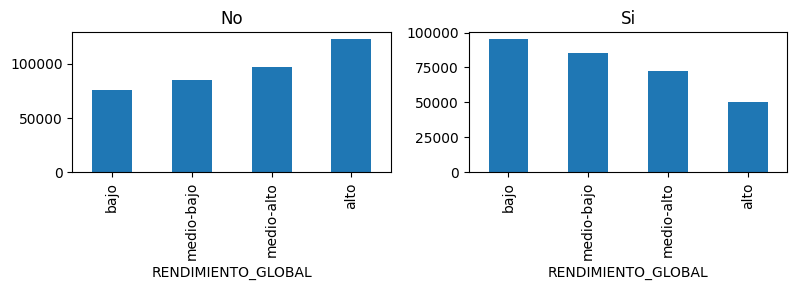

In [ ]:
from rlxutils import subplots
import matplotlib.pyplot as plt

c = sorted(z.ESTU_PAGOMATRICULAPROPIO.value_counts().index)
for ax,ci in subplots(c, n_cols=4, usizex=4):
    zc = z[z.ESTU_PAGOMATRICULAPROPIO==ci]
    zc.RENDIMIENTO_GLOBAL.value_counts()[['bajo', 'medio-bajo', 'medio-alto', 'alto']].plot(kind='bar')
    plt.title(ci)

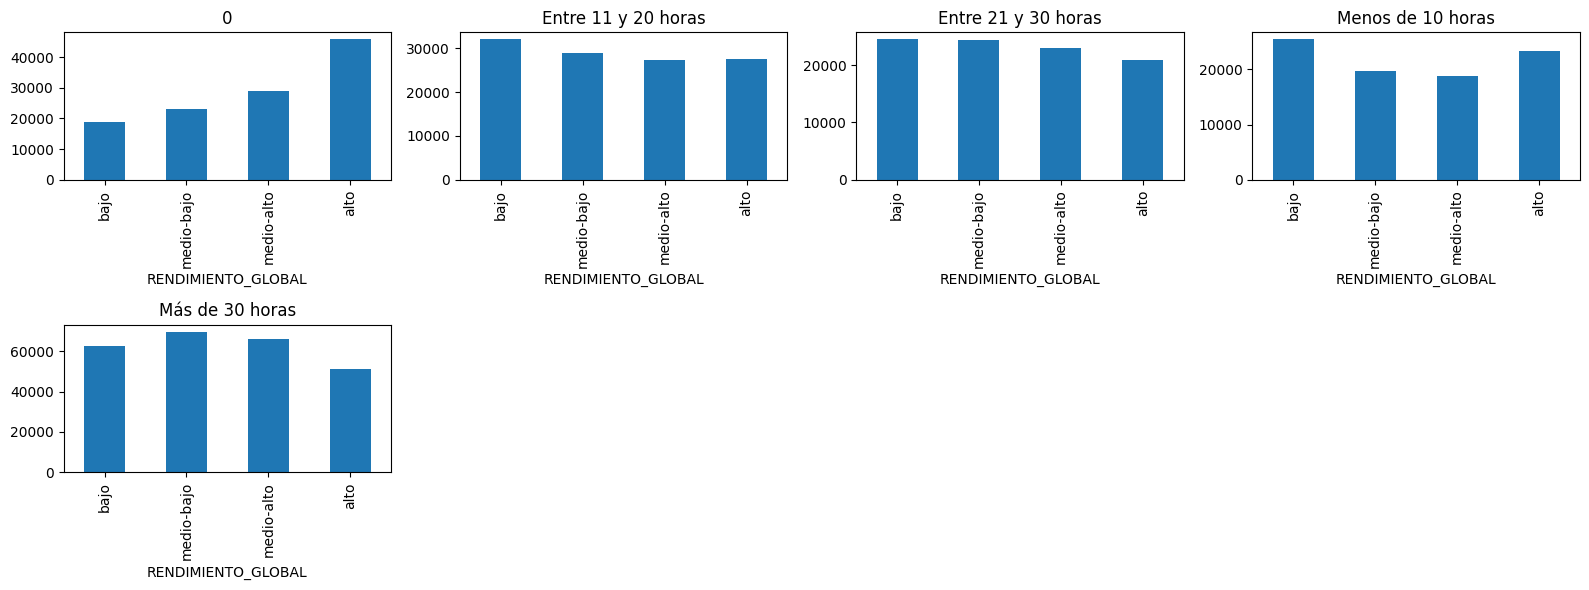

In [ ]:
from rlxutils import subplots
import matplotlib.pyplot as plt

c = sorted(z.ESTU_HORASSEMANATRABAJA.value_counts().index)
for ax,ci in subplots(c, n_cols=4, usizex=4):
    zc = z[z.ESTU_HORASSEMANATRABAJA==ci]
    zc.RENDIMIENTO_GLOBAL.value_counts()[['bajo', 'medio-bajo', 'medio-alto', 'alto']].plot(kind='bar')
    plt.title(ci)

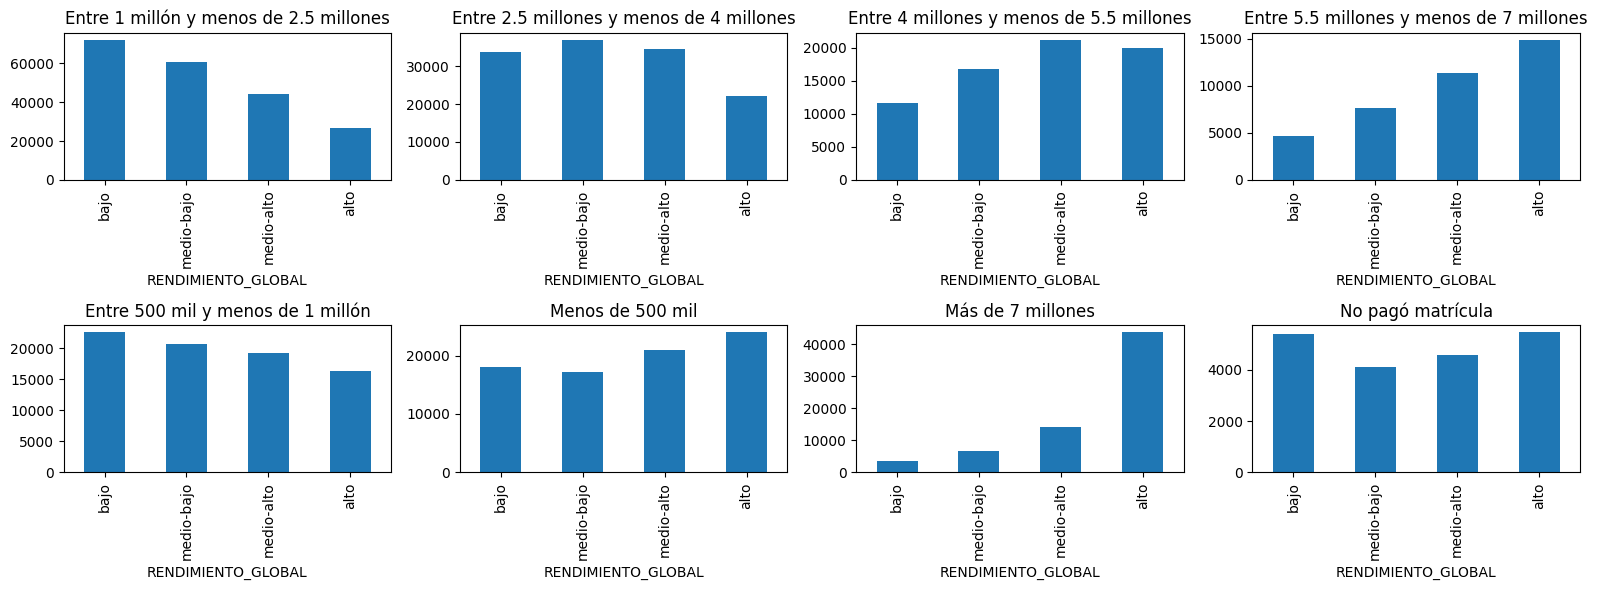

In [ ]:
from rlxutils import subplots
import matplotlib.pyplot as plt

c = sorted(z.ESTU_VALORMATRICULAUNIVERSIDAD.value_counts().index)
for ax,ci in subplots(c, n_cols=4, usizex=4):
    zc = z[z.ESTU_VALORMATRICULAUNIVERSIDAD==ci]
    zc.RENDIMIENTO_GLOBAL.value_counts()[['bajo', 'medio-bajo', 'medio-alto', 'alto']].plot(kind='bar')
    plt.title(ci)